In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from scipy.signal import find_peaks, peak_widths

In [2]:
data_dir = '/Volumes/raid_126TB/Mikrofluidik/2025/aligned_ants_selected/neurons/analysis'
outdir = f'{data_dir}/seizure_frequency'
os.makedirs(outdir, exist_ok=True)

use_detrended = True
variant = 'detrended' if use_detrended else 'original'
suffix = '_detrended' if use_detrended else ''

frame_rate_s = 3.25
compounds = ['control', 'PTZ', 'Tricaine']
colors = {'control': 'steelblue', 'PTZ': 'firebrick', 'Tricaine': '#7CA82A'}

selected_fish = {
    'control':  ['fish01', 'fish02', 'fish04', 'fish06', 'fish09'],
    'Tricaine': ['fish02', 'fish04', 'fish06', 'fish07', 'fish10'],
    'PTZ':      ['fish04', 'fish08', 'fish09', 'fish11', 'fish12'],
}

phases = {
    'habituation': (0, 185),
    'stimulus_1':  (185, 370),
    'recovery_1':  (370, 647),
    'stimulus_2':  (647, 832),
    'recovery_2':  (832, 1109),
}
phase_order = list(phases)
baseline_window = (90, 180)

# event detection on the population-mean ΔF/F signal ('pop_mean') 
# alternative: 'coactive_frac' (fraction of neurons above their own threshold)
co_signal = 'pop_mean'
active_k = 2.0            # a neuron is active at frame t if dF/F > base_mean + active_k * base_sd
smooth_frames = 3         # moving average on the co-activation signal before peak finding

# a peak counts as an event above max(baseline_mean + peak_k * baseline_sd, abs_min_dff)
peak_k = 4.0
abs_min_dff = 0.25
min_prominence_sd = 2.0   # required prominence (height of peak in comparison to surrounding level) in baseline SDs
min_iei_s = 10.0          # minimum inter-event interval in seconds

n_corr_subsample = 2000   # neurons subsampled per fish for the pairwise-correlation skewness
corr_seed = 0


**Loading per-neuron dFF data**

In [3]:
def load_dff_one_fish(fish, compound):

    dff_csv = f'{data_dir}/{fish}_{compound}_dFF_included_regions_zbrain{suffix}.csv'
    dff = pd.read_csv(dff_csv, index_col=0,
                      usecols=lambda c: str(c).startswith('Unnamed') or str(c).lstrip('-').isdigit())
    dff = dff[[str(i) for i in range(dff.shape[1])]]   # order columns numerically
    
    return dff.to_numpy(np.float32)

**Global and per-neuron co-activation**

In [4]:
# fraction of neurons above their baseline threshold and population mean dFF for each frame

def coactivation_signals(dff):

    b0, b1 = baseline_window
    base = dff[:, b0:b1]
    base_mean = base.mean(axis=1)
    base_sd = base.std(axis=1)
    valid = base_sd > 1e-6   # drop zero-variance neurons
    threshold = (base_mean + active_k * base_sd)[:, None]
    active = (dff > threshold) & valid[:, None]
    
    return {'coactive_frac': (active.sum(axis=0) / max(int(valid.sum()), 1)).astype(float),
            'pop_mean': dff[valid].mean(axis=0).astype(float)}
    

In [5]:
# for the co-active neuron map
# correlation of each neuron with the population mean dFF

def neuron_coactivity(dff, fish, compound):

    def coactivity_over(window):
        X = dff[:, window[0]:window[1]]
        pop = X.mean(axis=0, keepdims=True)
        Xz, pz = detrend_zscore(X), detrend_zscore(pop)
        return (Xz * pz).sum(axis=1) / max(X.shape[1], 1)   # per-neuron Pearson r with population

    stim_windows = [phases['stimulus_1'], phases['stimulus_2']]
    stim_coact = np.mean([coactivity_over(w) for w in stim_windows], axis=0)
    base_coact = coactivity_over(baseline_window)
    pop_active = np.mean([dff[:, a:b].mean() for a, b in stim_windows])

    cells_csv = f'{data_dir}/{fish}_{compound}_cells_included_regions_zbrain.csv'
    coords = pd.read_csv(cells_csv, index_col=0,
                         usecols=lambda c: str(c).startswith('Unnamed') or c in ('x', 'y', 'z'))
    neurons = pd.DataFrame({
        'fish': fish, 'compound': compound,
        'x': coords['x'].to_numpy(float),
        'y': coords['y'].to_numpy(float),
        'z': coords['z'].to_numpy(float),
        'coactivity': np.nan_to_num(stim_coact, nan=0.0),
        'baseline_coact': np.nan_to_num(base_coact, nan=0.0),
        'pop_active': float(pop_active),
    })
    return neurons[neurons[['x', 'y', 'z']].notna().all(axis=1)].copy()
    

**Seizure event detection**

In [6]:
# smooth slightly, find peaks above max(baseline_mean + peak_k * baseline_sd, abs_min_dff)
# fixed threshold per fish from the baseline, so that events are comparable across the two stimulations

def detect_events(signal):

    kernel = np.ones(smooth_frames) / smooth_frames
    sig = np.convolve(np.asarray(signal, float), kernel, mode='same')
    b0, b1 = baseline_window
    base_mean = float(np.mean(sig[b0:b1]))
    base_sd = max(float(np.std(sig[b0:b1])), 1e-9)
    cutoff = max(base_mean + peak_k * base_sd, abs_min_dff)
    distance = max(int(round(min_iei_s / frame_rate_s)), 1)

    peaks, props = find_peaks(sig, height=cutoff, distance=distance,
                              prominence=min_prominence_sd * base_sd)
    diagnostics = {'sig': sig, 'base_mean': base_mean, 'base_sd': base_sd, 'cutoff': cutoff}
    
    if len(peaks) == 0:
        empty = pd.DataFrame(columns=['peak_frame', 'peak_time_min', 'phase', 'amp_abs',
                                      'amp_rel', 'prominence', 'duration_s'])
        return empty, diagnostics

    widths = peak_widths(sig, peaks, rel_height=0.5)[0]      # full width at half maximum, frames
    rows = []
    for i, pk in enumerate(peaks):
        phase = next((name for name, (a, b) in phases.items() if a <= pk < b), None)
        rows.append({'peak_frame': int(pk),
                     'peak_time_min': pk * frame_rate_s / 60.0,
                     'phase': phase,
                     'amp_abs': float(sig[pk]),
                     'amp_rel': float(sig[pk] - base_mean),
                     'prominence': float(props['prominences'][i]),
                     'duration_s': float(widths[i] * frame_rate_s)})
        
    return pd.DataFrame(rows), diagnostics
    

In [7]:
def phase_event_rates(events, compound, fish):

    rows = []
    for phase, (a, b) in phases.items():
        duration_min = (b - a) * frame_rate_s / 60.0
        sub = events[events.phase == phase]
        n = len(sub)
        rows.append({'compound': compound, 'fish': fish, 'phase': phase,
                     'n_events': n,
                     'events_per_min': n / duration_min,
                     'amp_rel': float(sub.amp_rel.mean()) if n else np.nan,
                     'amp_abs': float(sub.amp_abs.mean()) if n else np.nan,
                     'prominence': float(sub.prominence.mean()) if n else np.nan,
                     'duration_s': float(sub.duration_s.mean()) if n else np.nan})
    return rows

**Network analysis**

In [8]:
# within-window linear detrend and z-score to remove slow trend (inflates correlations)

def detrend_zscore(M):
    
    M = np.asarray(M, float)
    t = np.arange(M.shape[1])
    tc = t - t.mean()
    denominator = float((tc ** 2).sum()) or 1.0
    slope = (M * tc).sum(axis=1) / denominator
    M = M - (slope[:, None] * tc + M.mean(axis=1, keepdims=True))
    sd = M.std(axis=1, keepdims=True)
    sd[sd == 0] = 1.0
    
    return M / sd

In [9]:
# mean population activity, co-active fraction and mean pairwise correlation per phase
# fixed random neuron sample

def network_metrics(dff, signals):

    rng = np.random.default_rng(corr_seed)
    n_sub = min(n_corr_subsample, dff.shape[0])
    sub = dff[rng.choice(dff.shape[0], size=n_sub, replace=False)]
    rows = []
    for phase, (a, b) in phases.items():
        segment = detrend_zscore(sub[:, a:b])
        C = np.nan_to_num(np.corrcoef(segment), nan=0.0)
        tri = C[np.triu_indices(C.shape[0], k=1)]
        rows.append({'phase': phase,
                     'pop_activity': float(np.mean(signals['pop_mean'][a:b])),
                     'coactive_pct': float(100.0 * np.mean(signals['coactive_frac'][a:b])),
                     'corr_mean': float(tri.mean())})
        
    return rows

**Analyze all fish**

In [10]:
def analyze_all():
    event_rows, rate_rows, net_rows, neuron_rows = [], [], [], []
    
    for compound in compounds:
        for fish in selected_fish[compound]:
            print(f'  {compound:8s} {fish} ...', flush=True)
            dff = load_dff_one_fish(fish, compound)
            signals = coactivation_signals(dff)
            events, _ = detect_events(signals[co_signal])
            events.insert(0, 'fish', fish)
            events.insert(0, 'compound', compound)
            event_rows.append(events)
            rate_rows.extend(phase_event_rates(events, compound, fish))
            
            for row in network_metrics(dff, signals):
                net_rows.append({'compound': compound, 'fish': fish, **row})
            neuron_rows.append(neuron_coactivity(dff, fish, compound))
            del dff
            
    return (pd.concat(event_rows, ignore_index=True),
            pd.DataFrame(rate_rows),
            pd.DataFrame(net_rows),
            pd.concat(neuron_rows, ignore_index=True))
    

**Bootstrap summary across fish and permutation test**

In [11]:
# resample fish with replacement

def bootstrap_ci(values, n_boot=10000, ci=95, seed=0):

    v = np.asarray(values, dtype=float)
    v = v[~np.isnan(v)]
    if v.size == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    boots = rng.choice(v, size=(n_boot, v.size), replace=True).mean(axis=1)
    lo, hi = np.percentile(boots, [(100 - ci) / 2, 100 - (100 - ci) / 2])
    
    return float(v.mean()), float(lo), float(hi)
    

In [12]:
# mean, bootsrap CI, SD, CV over the 5 fish per compound

def group_summary(per_fish, value_cols, by=('compound', 'phase')):

    by = list(by)
    rows = []
    for key, g in per_fish.groupby(by):
        key = key if isinstance(key, tuple) else (key,)
        rec = dict(zip(by, key))
        rec['n_fish'] = len(g)
        for m in value_cols:
            v = g[m].to_numpy(float)
            v = v[~np.isnan(v)]
            mean, lo, hi = bootstrap_ci(v)
            sd = float(np.std(v, ddof=1)) if v.size > 1 else np.nan
            rec[f'{m}_mean'] = mean
            rec[f'{m}_lo'] = lo
            rec[f'{m}_hi'] = hi
            rec[f'{m}_sd'] = sd
            rec[f'{m}_cv'] = (sd / mean) if (mean and np.isfinite(mean)) else np.nan
        rows.append(rec)
        
    return pd.DataFrame(rows)

In [13]:
# two sided permutation test for difference of per-fish means

def perm_test(a, b, n=10000, seed=0):

    a = np.asarray(a, float); a = a[~np.isnan(a)]
    b = np.asarray(b, float); b = b[~np.isnan(b)]
    
    if a.size == 0 or b.size == 0:
        return np.nan, np.nan
    observed = a.mean() - b.mean()
    pool = np.concatenate([a, b])
    rng = np.random.default_rng(seed)
    count = 0
    
    for _ in range(n):
        rng.shuffle(pool)
        if abs(pool[:len(a)].mean() - pool[len(a):].mean()) >= abs(observed) - 1e-12:
            count += 1
            
    return float(observed), float((count + 1) / (n + 1))
    

**Plotting**

In [14]:
# grouped bar chart

def plot_metric_by_phase(per_fish, metric, ylabel, title, path_to_save=None):

    rng = np.random.default_rng(0)
    fig, ax = plt.subplots(figsize=(9, 4.2))
    width = 0.25
    
    for j, compound in enumerate(compounds):
        for i, phase in enumerate(phase_order):
            v = per_fish[(per_fish.compound == compound) &
                         (per_fish.phase == phase)][metric].to_numpy(float)
            v = v[~np.isnan(v)]
            x = i + (j - 1) * width
            mean, lo, hi = bootstrap_ci(v)
            ax.bar(x, mean, width=width, color=colors[compound], alpha=0.8,
                   label=compound if i == 0 else None)
            if np.isfinite(mean):
                ax.errorbar(x, mean, yerr=[[max(mean - lo, 0)], [max(hi - mean, 0)]],
                            fmt='none', ecolor='k', capsize=2, lw=1)
            ax.scatter(x + rng.uniform(-0.05, 0.05, v.size), v, color='k', s=12,
                       alpha=0.55, zorder=3)
            
    ax.set_xticks(range(len(phase_order)))
    ax.set_xticklabels(phase_order, rotation=20, ha='right')
    ax.set_ylabel(ylabel, fontsize=14)
    ax.tick_params(axis='both', labelsize=14)
    # ax.set_title(title, fontsize=14)
    ax.legend(frameon=False, fontsize=12)
    fig.tight_layout()
    
    if path_to_save:
        fig.savefig(path_to_save, bbox_inches='tight')
        
    return fig, ax

In [15]:
# raster plot with z-scored dFF for one fish, random neuron sample
# global co-activation signal with cutoff and detected events

def plot_raster(fish, compound, n_show=400, path_to_save=None, seed=0, cmap='gray_r',
                vmin=0.25, vmax=4):

    dff = load_dff_one_fish(fish, compound)
    signals = coactivation_signals(dff)
    events, diagnostics = detect_events(signals[co_signal])

    rng = np.random.default_rng(seed)
    R = dff[rng.choice(dff.shape[0], size=min(n_show, dff.shape[0]), replace=False)]
    R = (R - R.mean(axis=1, keepdims=True)) / (R.std(axis=1, keepdims=True) + 1e-9)
    t_min = np.arange(dff.shape[1]) * frame_rate_s / 60.0

    fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(12, 6), sharex=True,
                                   gridspec_kw={'height_ratios': [2.0, 1.0]})
    ax0.imshow(R, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax,
               extent=[t_min[0], t_min[-1], 0, R.shape[0]], interpolation='nearest')
    ax0.set_ylabel(f'{R.shape[0]} neurons (subsample)', fontsize=18)
    ax0.tick_params(axis='y', labelsize=16)
    ax0.set_title('Seizure-like co-activation', fontsize=18)

    ax1.plot(t_min, diagnostics['sig'], color='k', lw=0.8)
    ax1.axhline(diagnostics['cutoff'], color='r', ls='--', lw=1, label='event cutoff')
    if len(events):
        ax1.scatter(events.peak_time_min, events.amp_abs, color='r', s=22, zorder=5,
                    label=f'{len(events)} events')
        
    ax1.set_ylabel('mean ΔF/F', fontsize=18)
    ax1.set_xlabel('time (min)', fontsize=18)
    ax1.tick_params(axis='both', labelsize=16)
    
    ax1.legend(frameon=False, loc='upper right', fontsize=14)
    for name, (a, b) in phases.items():
        if name.startswith('stimulus'):
            ax1.axvspan(a * frame_rate_s / 60, b * frame_rate_s / 60, color='0.85', zorder=0)
    fig.tight_layout()
    
    if path_to_save:
        fig.savefig(path_to_save, bbox_inches='tight')
        
    return fig, (ax0, ax1)

**Run analysis and save results as csv files**

In [16]:
events, rates, net, neurons = analyze_all()

events.to_csv(f'{outdir}/seizure_events_{variant}.csv', index=False)
rates.to_csv(f'{outdir}/seizure_rates_per_fish_{variant}.csv', index=False)
net.to_csv(f'{outdir}/seizure_network_per_fish_{variant}.csv', index=False)
neurons.to_csv(f'{outdir}/coactivity_per_neuron_{variant}.csv', index=False)

  control  fish01 ...
  control  fish02 ...
  control  fish04 ...
  control  fish06 ...
  control  fish09 ...
  PTZ      fish04 ...
  PTZ      fish08 ...
  PTZ      fish09 ...
  PTZ      fish11 ...
  PTZ      fish12 ...
  Tricaine fish02 ...
  Tricaine fish04 ...
  Tricaine fish06 ...
  Tricaine fish07 ...
  Tricaine fish10 ...


**Seizure event rate per phase**

(<Figure size 900x420 with 1 Axes>, <Axes: ylabel='events / min'>)

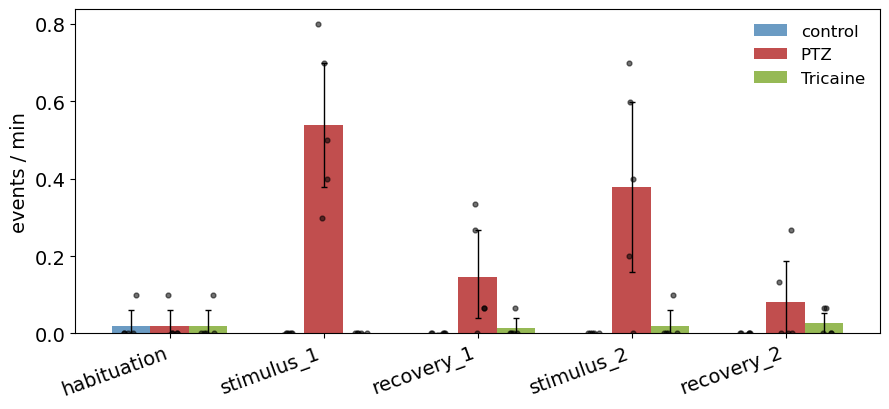

In [17]:
plot_metric_by_phase(rates, 'events_per_min', 'events / min', 'Seizure-like event rate',
                     path_to_save=f'{outdir}/events_per_min_by_phase_{variant}.pdf')

In [18]:
# group summary with bootstrap CIs
rate_summary = group_summary(rates, ['events_per_min', 'amp_rel', 'duration_s'])
rate_summary.to_csv(f'{outdir}/seizure_rate_summary_{variant}.csv', index=False)

**Network state characterization**

(<Figure size 900x420 with 1 Axes>, <Axes: ylabel='population mean ΔF/F'>)

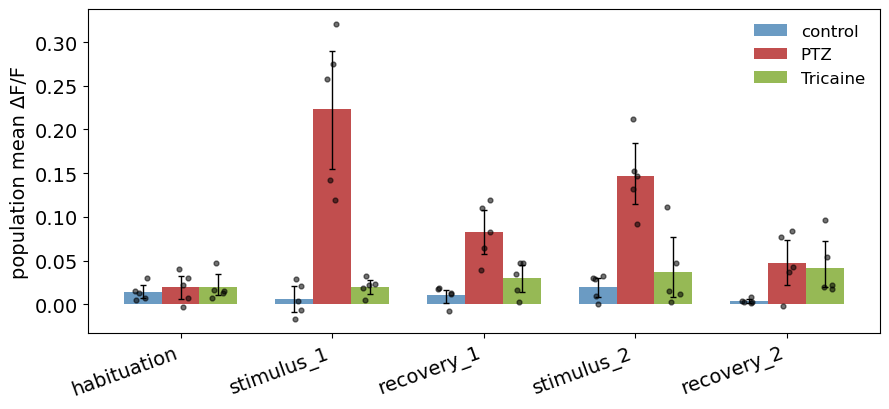

In [19]:
# Population activity
plot_metric_by_phase(net, 'pop_activity', 'population mean ΔF/F', 'Population activity',
                     path_to_save=f'{outdir}/pop_activity_by_phase_{variant}.pdf')

(<Figure size 900x420 with 1 Axes>, <Axes: ylabel='% co-active neurons'>)

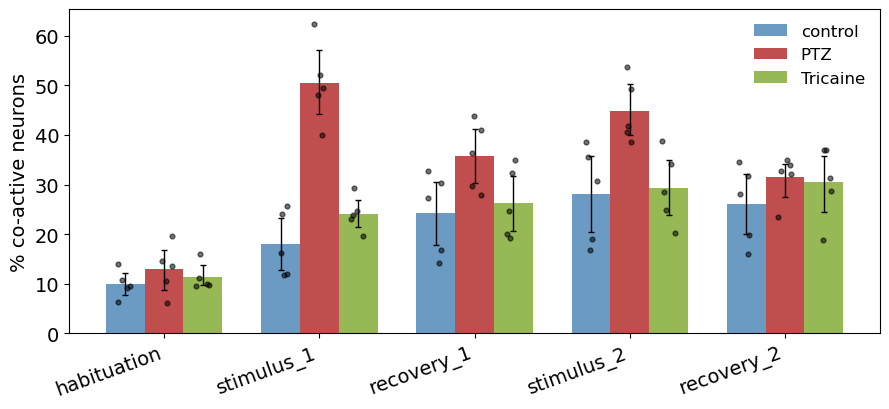

In [21]:
# Global co-activation 
plot_metric_by_phase(net, 'coactive_pct', '% co-active neurons', 'Co-active neuron fraction',
                     path_to_save=f'{outdir}/coactive_fraction_by_phase_{variant}.pdf')

(<Figure size 900x420 with 1 Axes>, <Axes: ylabel='mean pairwise correlation'>)

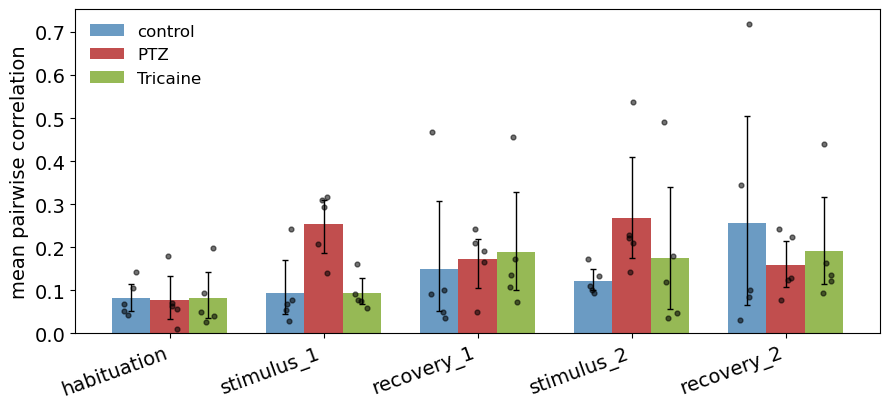

In [22]:
plot_metric_by_phase(net, 'corr_mean', 'mean pairwise correlation', 'Mean pairwise correlation',
                     path_to_save=f'{outdir}/corr_mean_by_phase_{variant}.pdf')

In [19]:
net_summary = group_summary(net, ['pop_activity', 'coactive_pct', 'corr_mean'])
net_summary.to_csv(f'{outdir}/seizure_network_summary_{variant}.csv', index=False)

**Raster plot and co-activation with event detection for PTZ fish**

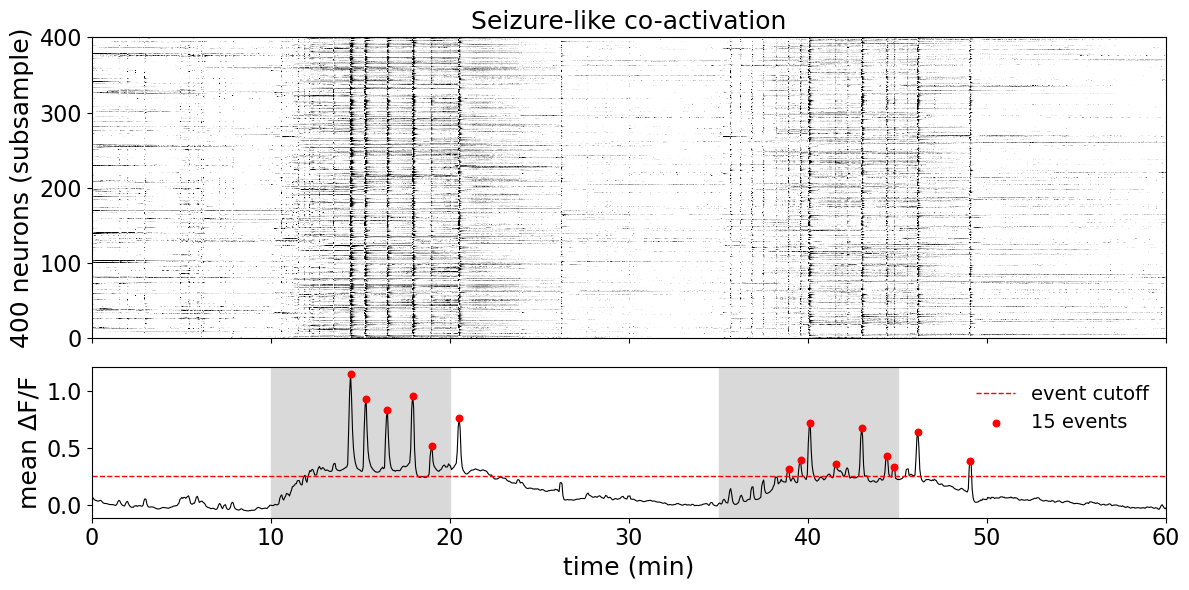

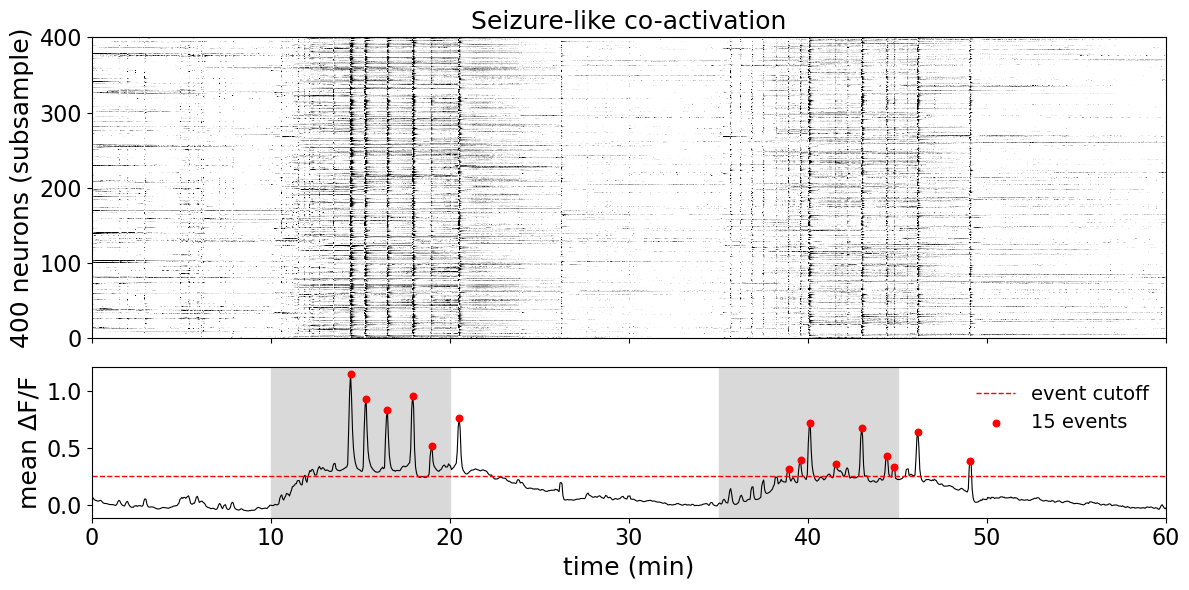

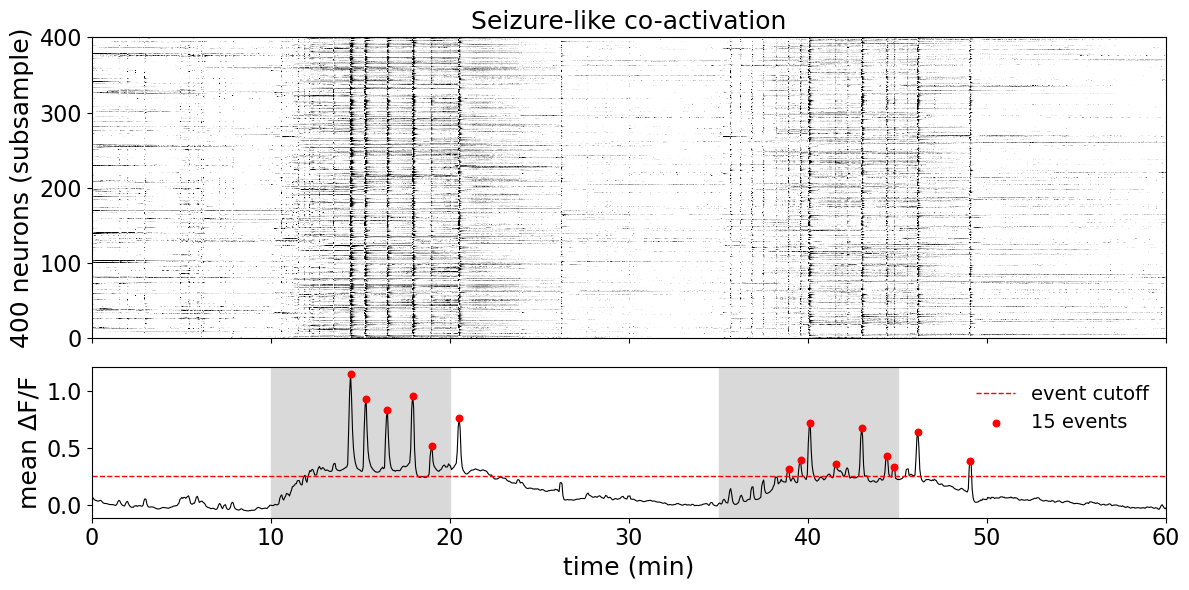

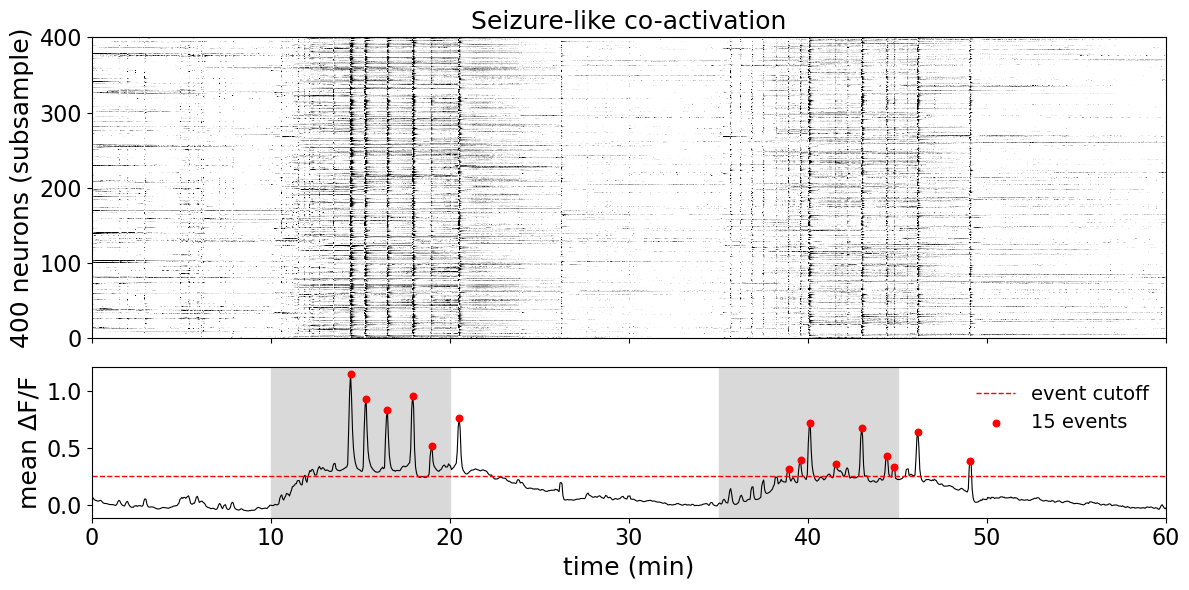

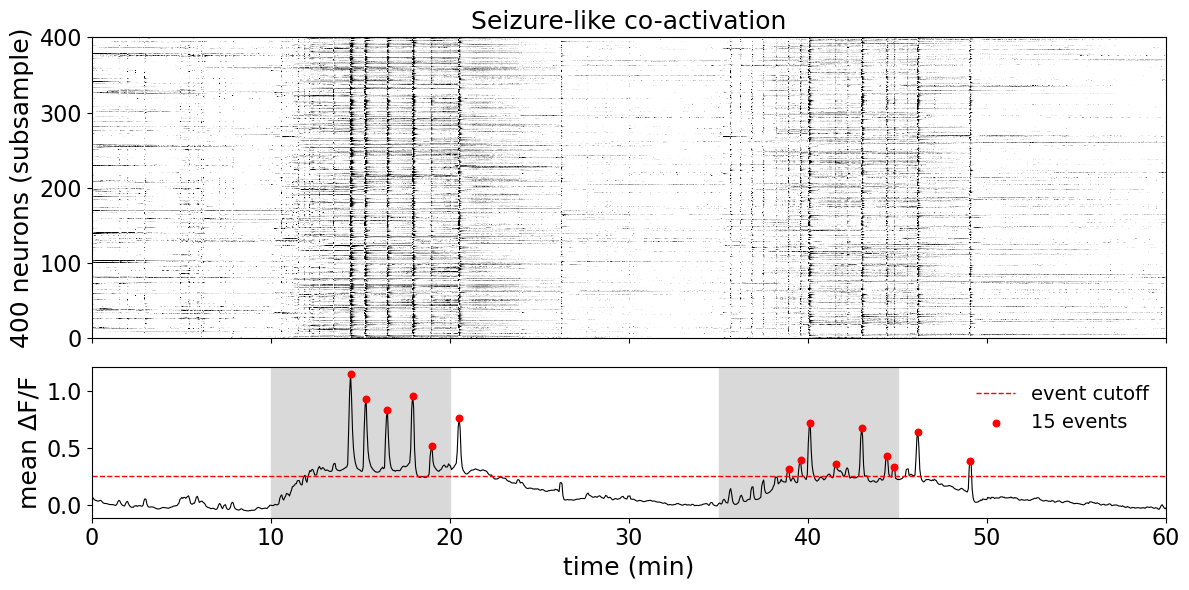

In [20]:
for fish in selected_fish['PTZ']:
    plot_raster('fish11', 'PTZ', n_show=400,
                path_to_save=f'{outdir}/raster_PTZ_{fish}_400_{variant}.pdf')